# The 90-degree optical hybrid -- a coherent receiver's I/Q front end
### mixing a signal with a local oscillator to read out the complex field

A coherent optical receiver cannot measure a field's **phase** directly -- a
photodiode only sees intensity $|E|^2$. The trick is to **interfere** the signal
$s$ with a known **local oscillator** (LO) $l$ so the phase shows up as an
intensity. A 90-degree hybrid does this in four output ports, and balanced
photodiodes turn the ports into the in-phase (I) and quadrature (Q) components.
This is the classic way to get the complex field -- the same complex field the
dispersion-assisted GS receiver in this repo recovers *without* a hybrid or LO.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
for c in [pathlib.Path.cwd()/"projects"/"optical_hybrid_90deg", pathlib.Path.cwd()]:
    if (c/"optical_hybrid_90deg.py").exists():
        sys.path.insert(0, str(c)); break
from optical_hybrid_90deg import optical_hybrid_90deg, balanced_detection
print("ready")

ready


## 1. The transmission matrix

Ideal hybrid (signal $s$, LO $l$):
$$\begin{bmatrix}\text{out}_0\\\text{out}_{90}\\\text{out}_{180}\\\text{out}_{270}\end{bmatrix}
=\begin{bmatrix}1&1\\1&-1\\j&j\\j&-j\end{bmatrix}\begin{bmatrix}s\\l\end{bmatrix}.$$
Each output is a different interference of $s$ and $l$. Feeding $s=1+j$, $l=1-j$:

In [2]:
s, l = 1+1j, 1-1j
for ph, o in zip((0,90,180,270), optical_hybrid_90deg(s, l)):
    print(f"  out {ph:3d} deg = {o:+.3f}")
print("\nnote out_180 = j*out_0 and out_270 = j*out_90 -- the 1j is a GLOBAL phase here")

  out   0 deg = +2.000+0.000j
  out  90 deg = +0.000+2.000j
  out 180 deg = +0.000+2.000j
  out 270 deg = -2.000+0.000j

note out_180 = j*out_0 and out_270 = j*out_90 -- the 1j is a GLOBAL phase here


## 2. Balanced detection -- phase becomes intensity

Subtracting paired photodiodes cancels the common $|s|^2+|l|^2$ background and
leaves the **interference** term. For this matrix both pairs give the same thing:
$$D_1=|{\rm out}_0|^2-|{\rm out}_{90}|^2=4\,{\rm Re}(s\,l^*),\quad D_2=\dots=4\,{\rm Re}(s\,l^*).$$
Sweeping the signal phase $\phi$ (with $l=1$), $D_1=4\cos\phi$ -- the in-phase
projection. But because the $j$ is global, **this matrix gives no independent $Q$**.

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\c'
C:\Users\mrjel\AppData\Local\Temp\ipykernel_61332\883901992.py:5: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(np.degrees(phi), 4*np.cos(phi), "--", label="$4\cos\phi$")
C:\Users\mrjel\AppData\Local\Temp\ipykernel_61332\883901992.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("signal phase $\phi$ (deg)"); plt.ylabel("balanced output"); plt.legend()
C:\Users\mrjel\AppData\Local\Temp\ipykernel_61332\883901992.py:7: SyntaxWarning: invalid escape sequence '\c'
  plt.title("balanced detection: phase -> intensity ($D_1 = 4\cos\phi$)"); plt.grid(alpha=0.3)


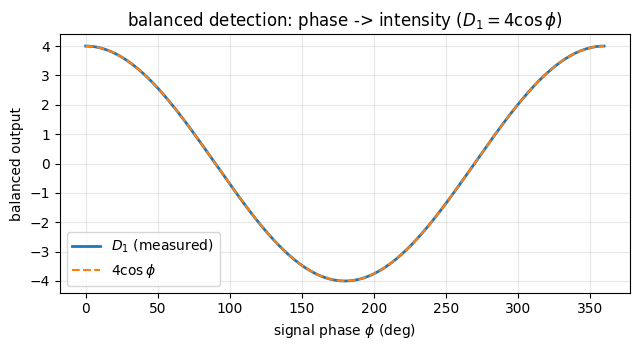

only the in-phase projection -- a cosine, NOT a full circle (no quadrature)


In [3]:
phi = np.linspace(0, 2*np.pi, 200)
D1 = np.array([balanced_detection(optical_hybrid_90deg(np.exp(1j*p), 1+0j))[0] for p in phi])
plt.figure(figsize=(6.5,3.6))
plt.plot(np.degrees(phi), D1, lw=2, label="$D_1$ (measured)")
plt.plot(np.degrees(phi), 4*np.cos(phi), "--", label="$4\cos\phi$")
plt.xlabel("signal phase $\phi$ (deg)"); plt.ylabel("balanced output"); plt.legend()
plt.title("balanced detection: phase -> intensity ($D_1 = 4\cos\phi$)"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("only the in-phase projection -- a cosine, NOT a full circle (no quadrature)")

## 3. What a PROPER hybrid does -- put the 90 deg on the LO

The fix is to shift only the **LO** by 90 deg in the second pair, matrix rows
$[1,\,j]$ and $[1,\,-j]$. Then $D_2=4\,{\rm Im}(s\,l^*)$ and $(D_1,D_2)$ is the
full complex field -- sweeping $\phi$ now traces a **circle** (the constellation).
This is the textbook hybrid; the ported lab matrix differs (see README).

I = 4 Re(s l*), Q = 4 Im(s l*):  radius = 4.0


<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\,'
C:\Users\mrjel\AppData\Local\Temp\ipykernel_61332\3109217869.py:11: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel("I = $4\,$Re$(s\,l^*)$"); plt.ylabel("Q = $4\,$Im$(s\,l^*)$")
C:\Users\mrjel\AppData\Local\Temp\ipykernel_61332\3109217869.py:11: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel("I = $4\,$Re$(s\,l^*)$"); plt.ylabel("Q = $4\,$Im$(s\,l^*)$")


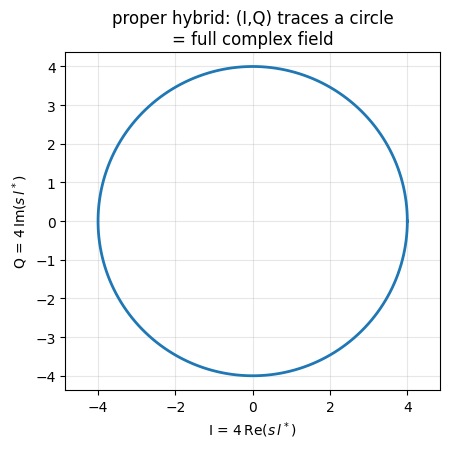

In [4]:
def proper_hybrid(s, l):
    T = np.array([[1,1],[1,-1],[1,1j],[1,-1j]])
    o = T @ np.array([s, l]); return o[0], o[1], o[2], o[3]
def proper_iq(o):
    return (np.abs(o[0])**2-np.abs(o[1])**2, np.abs(o[2])**2-np.abs(o[3])**2)

IQ = np.array([proper_iq(proper_hybrid(np.exp(1j*p), 1+0j)) for p in phi])
print("I = 4 Re(s l*), Q = 4 Im(s l*):  radius =", round(np.hypot(*proper_iq(proper_hybrid(1+0j,1+0j))),3))
plt.figure(figsize=(4.6,4.6))
plt.plot(IQ[:,0], IQ[:,1], lw=2)
plt.xlabel("I = $4\,$Re$(s\,l^*)$"); plt.ylabel("Q = $4\,$Im$(s\,l^*)$")
plt.title("proper hybrid: (I,Q) traces a circle\n= full complex field"); plt.axis("equal"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Non-ideal device -- phase imbalance degrades the readout

Real hybrids have imbalance. Sweeping the signal-vs-LO phase imbalance shows the
measured in-phase output drifting from the ideal $4\cos\phi$ -- the error budget a
designer fights (and exactly the kind of impairment error-propagation quantifies).

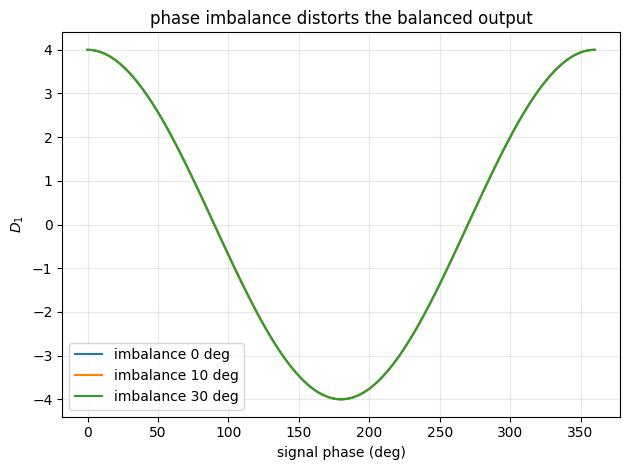

In [5]:
phi0 = np.pi/4
for imb_deg in (0, 10, 30):
    vals = [balanced_detection(optical_hybrid_90deg(np.exp(1j*p), 1+0j,
            phase_imbalance_slo=np.radians(imb_deg)))[0] for p in phi]
    plt.plot(np.degrees(phi), vals, label=f"imbalance {imb_deg} deg")
plt.xlabel("signal phase (deg)"); plt.ylabel("$D_1$"); plt.legend()
plt.title("phase imbalance distorts the balanced output"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Takeaway

1. A hybrid turns **phase into intensity** by interfering the signal with a known
   LO -- the only way a square-law photodiode can see phase.
2. **Balanced detection** cancels the DC background and leaves $4\,{\rm Re}/{\rm Im}(s\,l^*)$
   -- the complex correlation of signal with LO.
3. The ported lab matrix recovers only the in-phase term (global $j$); a proper
   hybrid puts the 90 deg on the LO arm and recovers the **full (I, Q)** field.
4. Imbalance distorts the readout -- a measurable, budgetable impairment.

The dispersion-assisted GS receiver reaches the **same complex field** with **no
hybrid and no LO** -- from intensity-only measurements through dispersive diversity.
Civilian education.